In [1]:
import _thread
import time
from queue import Queue
import threading
import time
import numpy as np
# def input_thread(a_list):
#     input()             # use input() in Python3
#     a_list.append(True)
    
# def do_stuff():
#     a_list = []
#     _thread.start_new_thread(input_thread, (a_list,))
#     num = 1
#     while not a_list:
#         num += 1
#         print(num)
#         time.sleep(0.5)

In [2]:
from queue import Queue
import threading
import time
import numpy as np

count_queue = Queue(maxsize=1)
counter = 0

def count_func():
    global counter
    while True: #need a loop in the multithreaded funtion for it to continuously run
        if count_queue.full():
            count_queue.get_nowait()
        count_queue.put(counter)
        counter += 1
        time.sleep(0.05)   # control update rate

threading.Thread(target=count_func, daemon=True).start()

counter2 = 0
while True:
    time.sleep(np.random.random())
    print(f'while loop runs {counter2}, function runs {count_queue.get()}')
    counter2 += 1

while loop runs 0, function runs 16
while loop runs 1, function runs 33
while loop runs 2, function runs 45
while loop runs 3, function runs 49
while loop runs 4, function runs 64
while loop runs 5, function runs 77
while loop runs 6, function runs 84
while loop runs 7, function runs 90
while loop runs 8, function runs 103
while loop runs 9, function runs 109
while loop runs 10, function runs 114
while loop runs 11, function runs 130
while loop runs 12, function runs 134
while loop runs 13, function runs 147
while loop runs 14, function runs 162
while loop runs 15, function runs 166


KeyboardInterrupt: 

In [35]:
from queue import Queue
import threading
import time
import Hand_tracking as ht
from hand_tracking_sdk import JointName

client = ht.create_client(port=8000)
frame_queue = Queue(maxsize=1)

def frame_producer(stop_event):
    try:
        for frame in client.iter_events():
            if stop_event.is_set():
                break

            try:
                frame_queue.put(frame, block=False)
            except:
                frame_queue.get_nowait()
                frame_queue.put(frame)

    finally:
        # VERY IMPORTANT: close socket
        try:
            client.close()
            print('client closed')
        except:
            pass

stop_event = threading.Event()
producer_thread = threading.Thread(
    target=frame_producer,
    args=(stop_event,),
    daemon=False
)
producer_thread.start()

try:
    while True:
        time.sleep(1)
        try:
            frame = frame_queue.get_nowait()
            curls = ht.normalize_curl(ht.finger_curls(frame_queue.get(timeout=0.5)))
            head_dict = frame.to_dict()['head']
            wx,wy,wz = frame.get_joint(JointName.WRIST)
            print(f'\rGot curls: {curls}')
            print(f'\rGot head x:{head_dict['x']} y:{head_dict['y']} z:{head_dict['z']}')
            print(f'\rGot wrist{wx} {wy} {wz}')
        except:
            print('\rNo frame yet', end='')
except KeyboardInterrupt:
    print("\nStopping...")
    # stop_event.set()   #  signal thread to stop
    producer_thread.join()      #  wait for it to finish

Exception in thread Thread-135 (frame_producer):
Traceback (most recent call last):
  File "/Users/martikyl004/.local/share/uv/python/cpython-3.13.12-macos-aarch64-none/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/Users/martikyl004/.local/share/uv/python/cpython-3.13.12-macos-aarch64-none/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/c7/5l4htc7s35b8h42nt9dh4qzw0000gn/T/ipykernel_26508/3432202066.py", line 12, in frame_producer
    for frame in client.iter_events():
                 ~~~~~~~~~~~~~~~~~~^^
  File "/Users/martikyl004/Downloads/Python_stuff/Tech studio project/.venv/lib/python3.13/site-packages/hand_tracking_sdk/client.py", line 209, in iter_events
    with receiver:
         ^^^^^^^^
  File "/Users/martikyl004/Downloads/Python_stuff/Tech studio project/.venv/lib/python3.13/site-packages/hand_tracking_sdk/tra

No frame yet
Stopping...


In [29]:
from hand_tracking_sdk import JointName
# ht.joint_vec(frame, JointName.WRIST)
frame.frame_id
ht.normalize_curl(ht.finger_curls(frame))



AttributeError: 'HeadFrame' object has no attribute 'get_joint'

In [ ]:
# Source - https://stackoverflow.com/a/70558417
# Posted by RSale, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-05, License - CC BY-SA 4.0

import pandas as pd
def clearvars():    
    for el in sorted(globals()):
        if '__' not in el:
                print(f'deleted: {el}')
                del el
clearvars()



In [ ]:
# import Hand_tracking as ht
from hand_tracking_sdk import HTSClient, HTSClientConfig, JointName, StreamOutput
from queue import Queue
import threading
import time
import Hand_tracking as ht

client = ht.create_client(port=8000)

frame_queue = Queue(maxsize=1)

COUNTER = 0
def frame_producer():
    global client
    for frame in client.iter_events():
        # COUNTER += 1
        if frame_queue.full():
            frame_queue.get_nowait()
            frame_queue.put(frame)


threading.Thread(target=frame_producer, daemon=True).start()

while True:
    # time.sleep(1)
    try:
        frame = frame_queue.get_nowait()
        curls = ht.normalize_curl(ht.finger_curls(frame_queue.get()))
        print(f'\rGot curls: {curls}', end='')
    except:
        print('\rNo frame yet', end='')
    # curls = ht.normalize_curl(ht.finger_curls(frame_queue.get()))
    # print(end='\r')
    # for curl in curls:
    #     print('index', ht.draw_bar(curl),end='')

In [3]:
import pandas as pd
import numpy as np

def fill_df_with_test_data(
    df,
    dominant_curl_by_pin=None,
    noise=0.02,
    dead_zone=(0.0, 0.15),
    seed=42,
):
    """
    Fill NaNs in a multi-index dataframe with synthetic test data.

    dominant_curl_by_pin:
        dict like {2: "IMCURL", 5: "RPCURL", 12: "TCURL"}
        If None, it will rotate dominance automatically.
    """

    rng = np.random.default_rng(seed)
    df = df.copy()

    curls = ["IMCURL", "RPCURL", "TCURL","IM", "RP", "T"]
    # raw = ["IM", "RP", "T"]

    pins = df.index.get_level_values("servo pin").unique()

    # Auto-assign dominant curl per pin if not provided
    if dominant_curl_by_pin is None:
        dominant_curl_by_pin = {
            pin: curls[i % 3] for i, pin in enumerate(pins)
        }

    for pin in pins:
        pin_mask = df.index.get_level_values("servo pin") == pin
        stim = df.loc[pin_mask].index.get_level_values("stim_level").to_numpy()

        # Normalize stim 0–1
        s = (stim - stim.min()) / (stim.max() - stim.min())

        # Dead zone mask
        reactive = s > dead_zone[1]

        # Nonlinear response curve
        base_curve = np.zeros_like(s)
        base_curve[reactive] = np.sin(s[reactive] * np.pi / 2) ** 1.5

        for curl in curls:
            col = curl
            raw_col = curl.replace("CURL", "")

            if curl == dominant_curl_by_pin[pin]:
                response = base_curve
            else:
                response = 0.15 * base_curve  # cross-coupling

            response += rng.normal(0, noise, size=response.shape)

            # Fill only NaNs
            df.loc[pin_mask & df[col].isna(), col] = response[df[col].isna()[pin_mask]]
            df.loc[pin_mask & df[raw_col].isna(), raw_col] = response[df[raw_col].isna()[pin_mask]]

    return df
max_stim = 100
starting_stim = 0
stim_levels = range(starting_stim,max_stim+1)
servo_pin_list = [2,4,6,8,10,12] # pins to calibrate back curl with
multindex = pd.MultiIndex.from_product([servo_pin_list, stim_levels ], names=["servo pin", "stim_level"])
df = pd.DataFrame(index=multindex, columns=['IM','RP','T','IMCURL','RPCURL','TCURL'])
df_filled = fill_df_with_test_data(df,noise=0.1)

In [14]:
pins = df.index.get_level_values("servo pin").unique()
curls = ["IMCURL", "RPCURL", "TCURL","IM", "RP", "T"]
dict = {pin: curls[i % 6] for i, pin in enumerate(pins)}

In [5]:
def build_curl_controller(df, target="IMCURL", others=("RPCURL", "TCURL"), thresh=0.05):

    reactive = df.dropna(subset=[target])

    score = (
        reactive
        .assign(
            selectivity=lambda x:
                x[target].abs()
                - x[list(others)].abs().sum(axis=1)
        )
        .groupby(level="servo pin")["selectivity"]
        .mean()
    )
    # import pdb;pdb.set_trace()
    score = pd.to_numeric(score, errors='coerce').fillna(0, downcast='infer')
    best_pin = score.idxmax()

    pin_df = df.xs(best_pin, level="servo pin")
    pin_df = pin_df[pin_df[target].abs() > thresh]

    stim = pin_df.index.to_numpy(dtype=float)
    curl = pin_df[target].to_numpy()

    stim_norm = (stim - stim.min()) / (stim.max() - stim.min()) * 100

    mapper = lambda u: np.interp(np.clip(u, 0, 100), curl.tolist(), stim_norm.tolist())

    return best_pin, mapper


def compute_pin_heatmap(
    df,
    columns=None,
    threshold=0.00,
    agg="mean",
):
    """
    Compute pin × signal heatmap values.

    df: MultiIndex DataFrame (servo pin, stim_level)
    columns: list of columns to score (default = all curl columns)
    threshold: dead-zone cutoff
    agg: 'mean' | 'max' | 'sum'
    """

    if columns is None:
        columns = [c for c in df.columns]# if "CURL" in c]

    # Remove dead zones
    active = df[columns].where(df[columns].abs() > threshold)

    # Aggregate over stim_level
    grouped = active.groupby(level="servo pin")

    if agg == "mean":
        heatmap = grouped.mean()
    elif agg == "max":
        heatmap = grouped.max()
    elif agg == "sum":
        heatmap = grouped.sum()
    else:
        raise ValueError("agg must be 'mean', 'max', or 'sum'")

    return heatmap

import seaborn as sns
import matplotlib.pyplot as plt

def plot_pin_heatmap(
    heatmap_df,
    title="Pin vs Output Heatmap",
    cmap="viridis",
    annotate=True,
):
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heatmap_df,
        cmap=cmap,
        annot=annotate,
        fmt=".3f",
        linewidths=0.5,
    )
    sns.heatmap(heatmap_df, cmap ='RdYlGn', linewidths = 0.30, annot = True)
    plt.title(title)
    plt.ylabel("Servo Pin")
    plt.xlabel("Output")
    plt.tight_layout()
    plt.show()

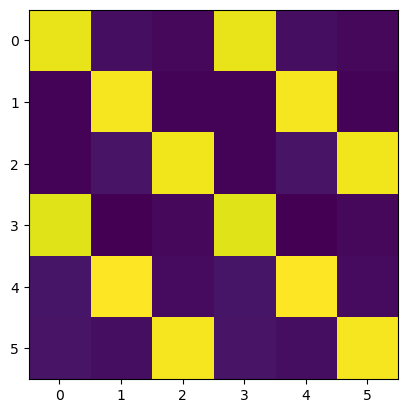

In [6]:
hmap = compute_pin_heatmap(df_filled, agg='sum')
hmap = hmap.to_numpy(dtype=float)
plt.imshow(hmap)

In [ ]:
# plot_stims = df_filled['IMCURL'][4].index.to_numpy(dtype=float)
# plot_curls = df_filled['IMCURL'][4].to_numpy(dtype=float)
# plt.plot(plot_stims,plot_curls)


In [15]:
fig_curls = []
for curl in curls:
    fig_curls.append(curl)
    fig_curls.append(curl)
print(fig_curls)

['IMCURL', 'IMCURL', 'RPCURL', 'RPCURL', 'TCURL', 'TCURL', 'IM', 'IM', 'RP', 'RP', 'T', 'T']


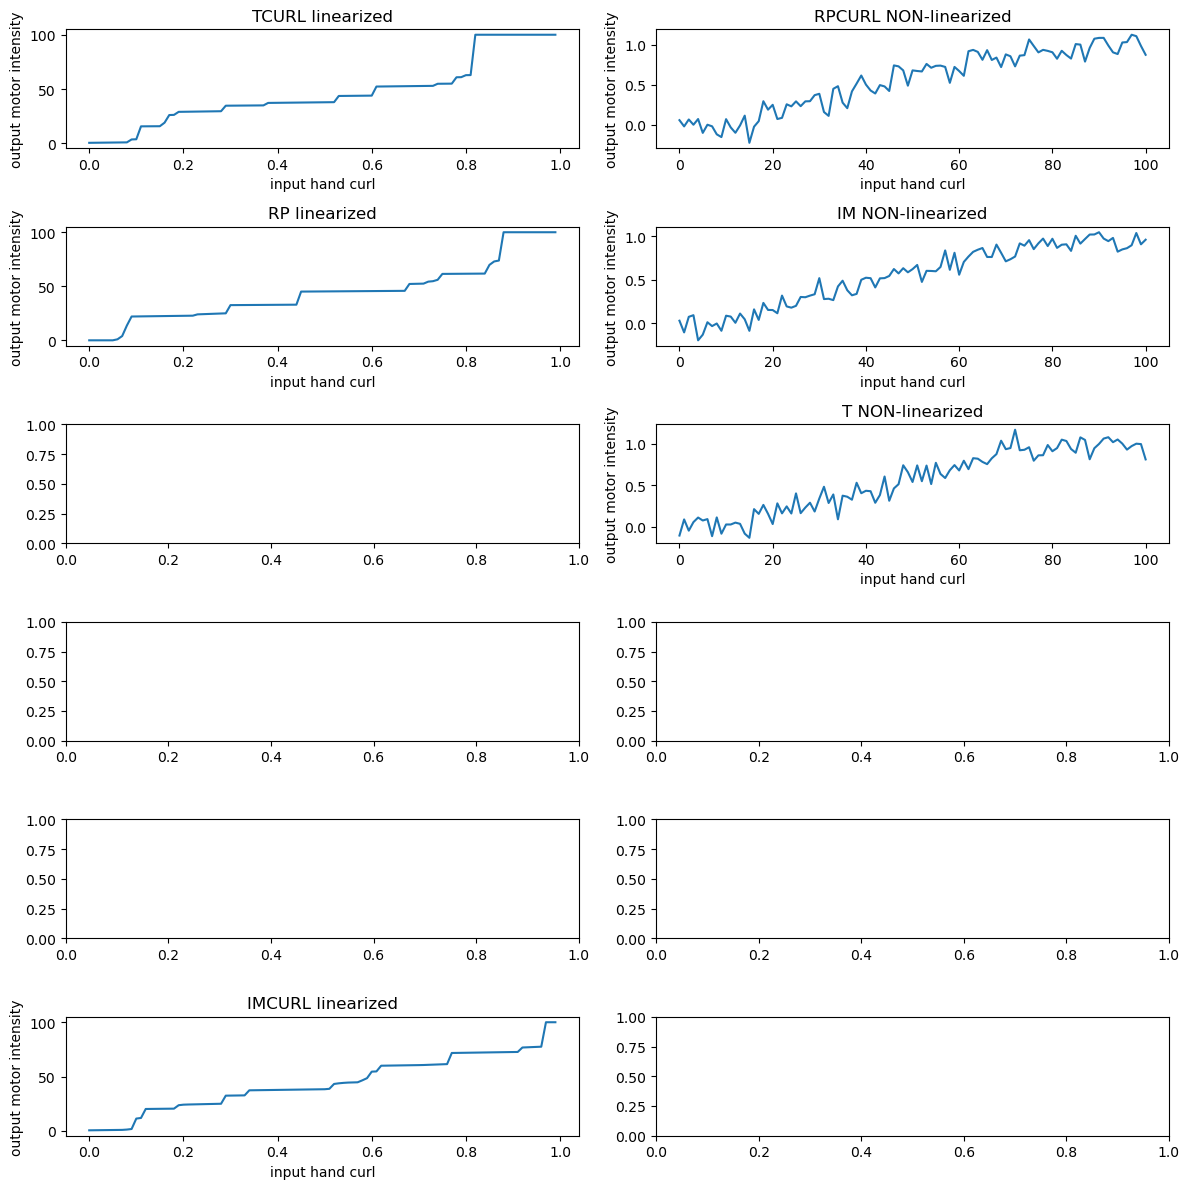

In [ ]:
controller_df = pd.DataFrame(index=curls,columns=['best_pin','mapper'])
for curl in curls:
    controller_df['best_pin'][curl], controller_df['mapper'][curl] = build_curl_controller(df_filled, target=curl)

x = np.arange(0,1,0.01)
fig, axes = plt.subplots(len(curls),2,figsize=(12,2*len(curls)))
fig_curls = []
for curl in curls:
    fig_curls.append(curl)
    fig_curls.append(curl)
for curl,counter in zip(fig_curls,range(1,(len(fig_curls))+1)):
    if counter%2==1:
        y = np.empty(0)
        for i in x:
            y = np.append(y,controller_df['mapper'][curl](i))
        ax = axes[(counter//2)-1,0]
        ax.plot(x,y)
        ax.set_title(f'{str(curl)} linearized')
        ax.set_xlabel('input hand curl')
        ax.set_ylabel('output motor intensity')
    else:
        plot_stims = df_filled[curl][controller_df['best_pin'][curl]].index.to_numpy(dtype=float)
        plot_curls = df_filled[curl][controller_df['best_pin'][curl]].to_numpy(dtype=float)
        # plot not linearized response
        ax = axes[(counter//2)-1,1]
        ax.plot(plot_stims,plot_curls)
        ax.set_title(f'{str(curl)} NON-linearized')
        ax.set_xlabel('input hand curl')
        ax.set_ylabel('output motor intensity')
fig.tight_layout()